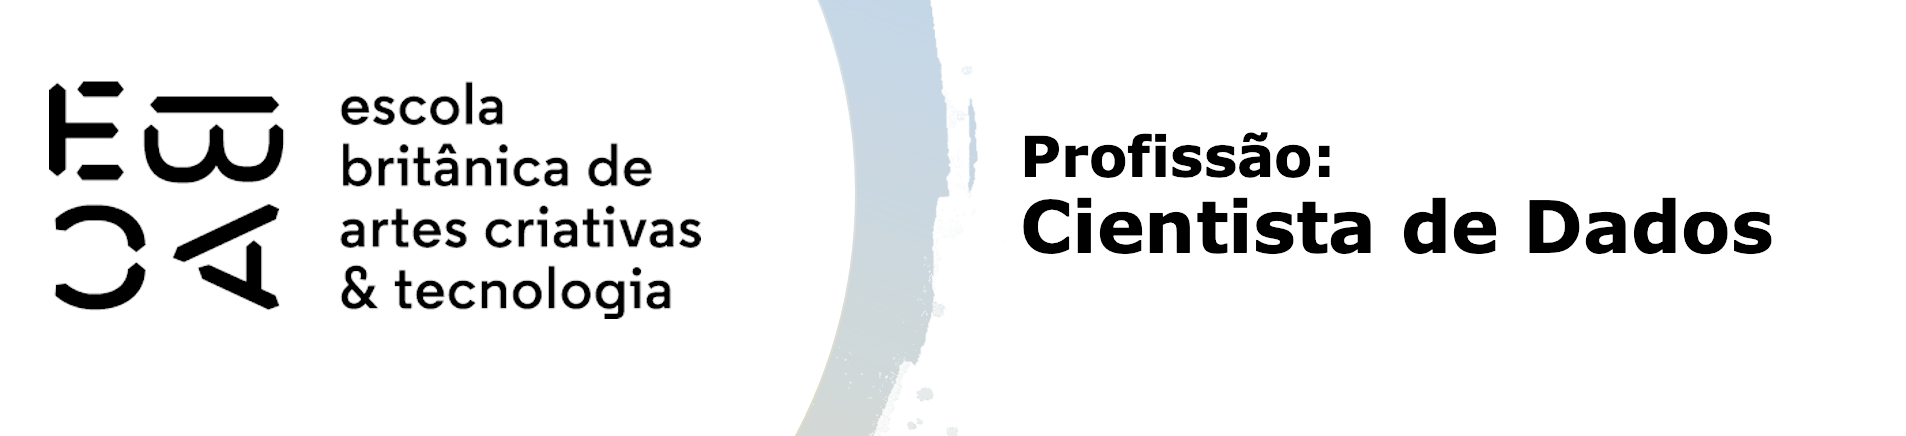

# Métodos hierárquicos de agrupamento - Tarefa

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

import scipy.cluster.hierarchy as shc

## 1) Repetindo o que fizemos em aula

Primeiramente vamos repetir o que fizemos em aula com a base de pinguins.

1. Selecione as variáveis quantitativas da base de pinguins
2. Elimine valores faltantes
3. Padronize as variáveis para média zero e desvio padrão 1
4. Faça um agrupamento hierárquico dividindo essa base em 3 grupos
5. Faça o Dendrograma

In [5]:
peng = sns.load_dataset('penguins')
peng.index.name='id'
peng_num = peng.select_dtypes(include='number').dropna()

In [6]:
padronizador = StandardScaler()
peng_pad = padronizador.fit_transform(peng_num)

In [7]:
clus = AgglomerativeClustering(linkage="complete", 
                                 distance_threshold = None, 
                                 n_clusters=3)

In [8]:
clus.fit(peng_pad)

AgglomerativeClustering(linkage='complete', n_clusters=3)

In [9]:
peng_num['grupo'] = clus.labels_
peng_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,grupo
id,,,,,
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
4,36.7,19.3,193.0,3450.0,1
5,39.3,20.6,190.0,3650.0,1


In [10]:
peng = peng.merge(peng_num['grupo'], how='left', on='id')

In [11]:
peng.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,grupo
id,,,,,,,,
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.0


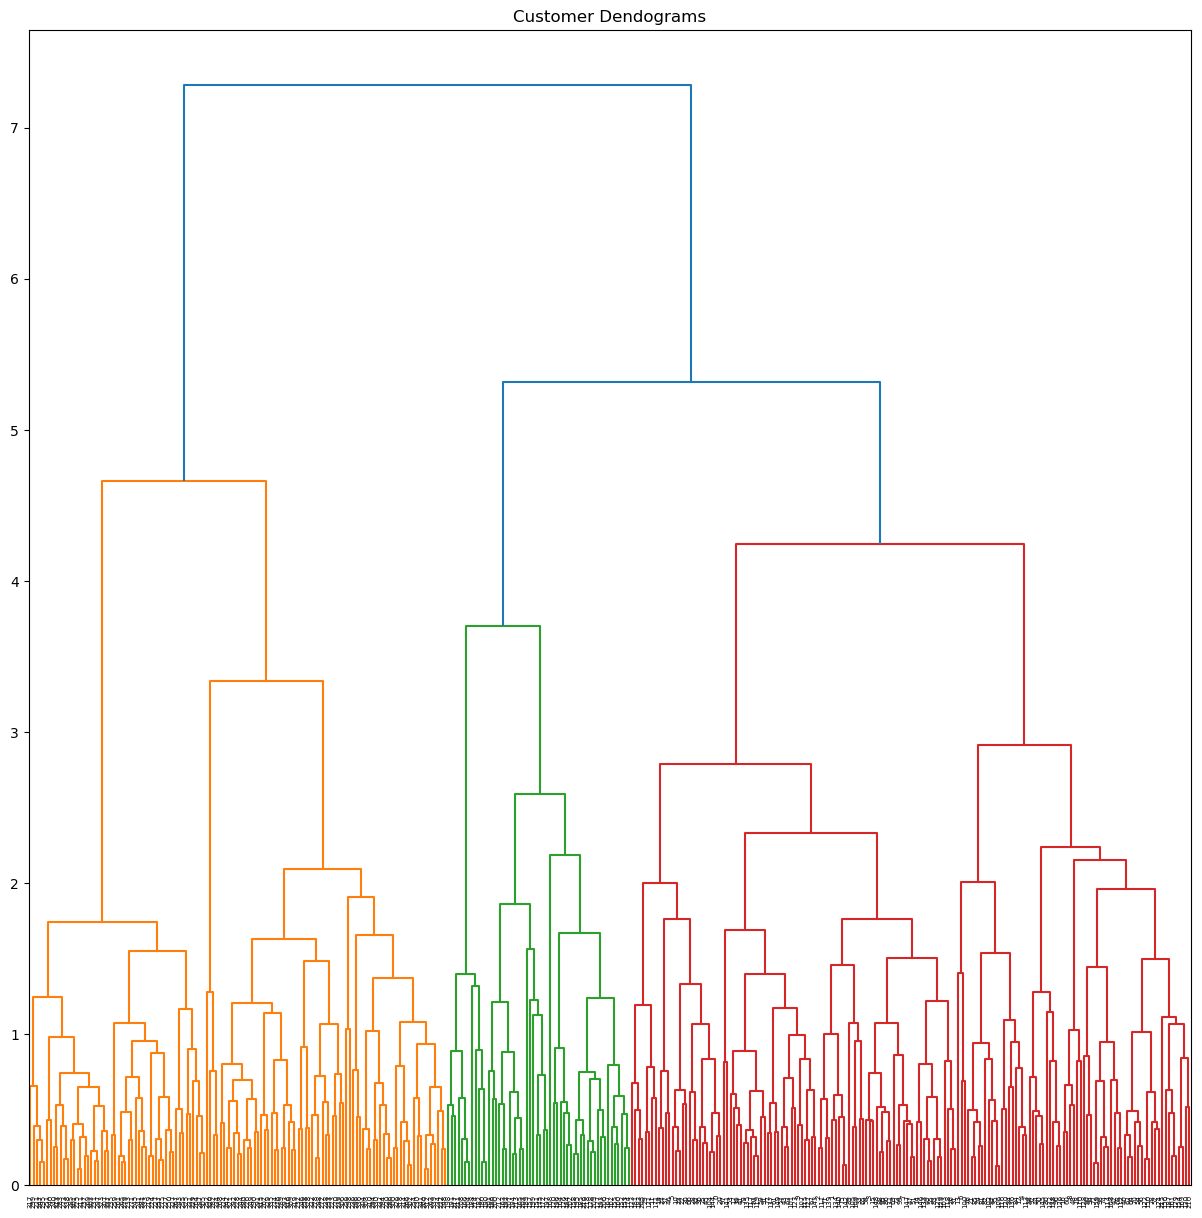

In [12]:
plt.figure(figsize=(15, 15))

plt.title("Customer Dendograms")

dend = shc.dendrogram(shc.linkage(peng_pad, method='complete'))

## 2) Avalie os grupos

Descreva os grupos:

- Quantos pinguins de cada espécie há em cada grupo?
- Descreva as variáveis quantitativas de cada grupo com as técnicas que você preferir.

In [14]:
pd.crosstab(peng['species'], peng['grupo'])

grupo,0.0,1.0,2.0
species,,,
Adelie,0,151,0
Chinstrap,0,14,54
Gentoo,123,0,0


C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

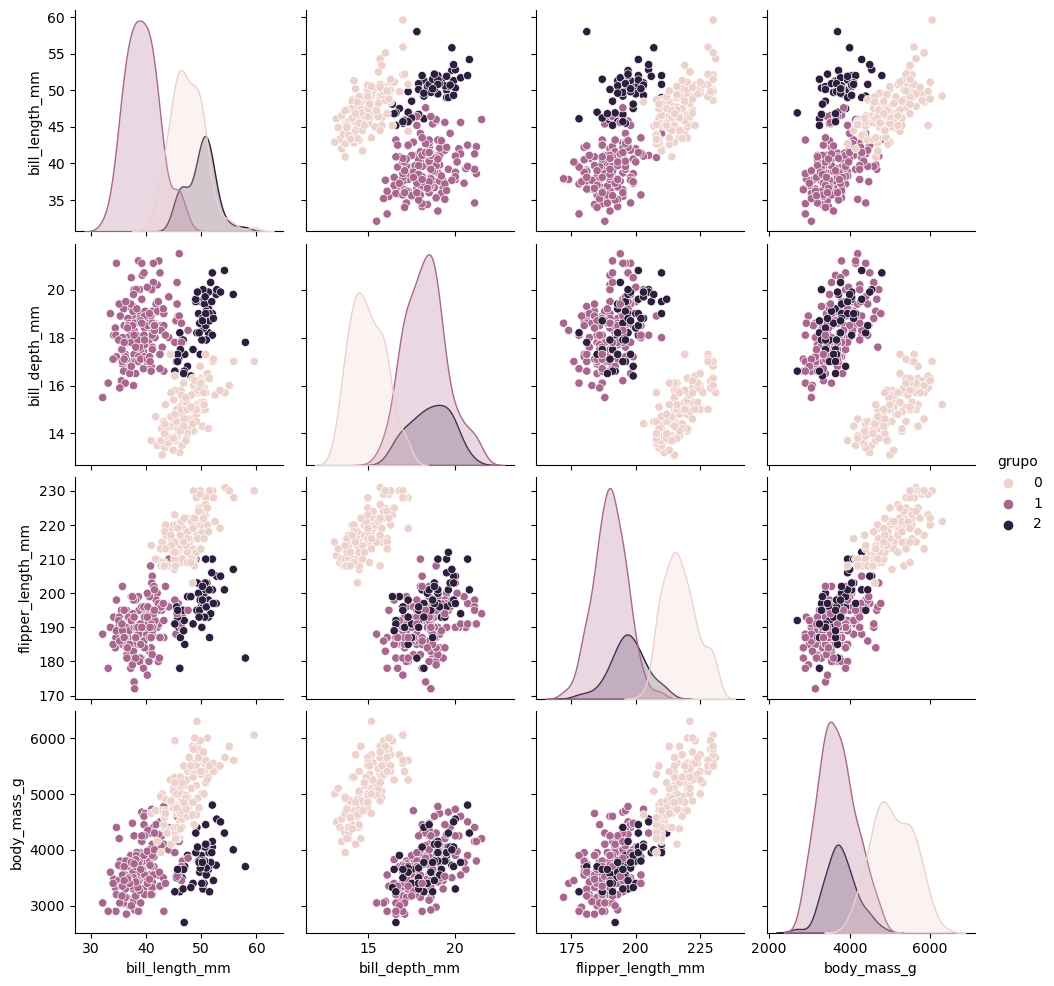

In [15]:
sns.pairplot(data = peng_num, hue = 'grupo')

## 3) Alterando o agrupamento

O Dendrogarma sugere que podemem haver grupos interessantes se solicitarmos mais que 3 grupos. Se quisermos testar o agrupamento com mais de 3 grupos, quantos grupos o Dendrograma te sugere? (Dica: não faça mais que 6 grupos).

- Faça o agrupamento hierárquico semelhante ao anterior, mas com o número de grupos que você escolheu.
- Analise esses agrupamentos
    - Quantos pinguins de cada espécie há em cada grupo?
    - Quantos pinguins de cada espécie machos e fêmeas há em cada grupo?
- Na sua opinião, o agrupamento capturou algum padrão natural dos dados? Qual?

O dendrograma mostra que inicialmente temos três grupos principais bem distribuídos. No entanto, ao abaixar um pouco a linha de corte no eixo y, conseguimos dividir o grupo laranja em dois subgrupos que ainda mantêm uma boa distribuição. Se abaixarmos mais um pouco, o grupo vermelho também se divide bem em dois grupos. A próxima divisão seria no grupo verde, mas nesse caso, um dos subgrupos ficaria com poucos elementos, o que não seria tão útil para a análise. Por isso, a melhor escolha é manter o grupo verde como está e dividir apenas os grupos vermelho e laranja, resultando em um total de cinco grupos. Dessa forma, conseguimos separar melhor os dados sem perder qualidade ou equilíbrio entre os grupos.

In [18]:
clus = AgglomerativeClustering(linkage="complete", 
                                 distance_threshold = None, 
                                 n_clusters=5)

In [19]:
clus.fit(peng_pad)

AgglomerativeClustering(linkage='complete', n_clusters=5)

In [20]:
peng_num['grupo'] = clus.labels_
peng_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,grupo
id,,,,,
0,39.1,18.7,181.0,3750.0,4
1,39.5,17.4,186.0,3800.0,4
2,40.3,18.0,195.0,3250.0,4
4,36.7,19.3,193.0,3450.0,4
5,39.3,20.6,190.0,3650.0,2


In [21]:
peng = peng.merge(peng_num['grupo'], how='left', on='id')
peng.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,grupo_x,grupo_y
id,,,,,,,,,
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1.0,4.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1.0,4.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1.0,4.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.0,4.0


In [22]:
pd.crosstab(peng['species'], peng['grupo_y'])

grupo_y,0.0,1.0,2.0,3.0,4.0
species,,,,,
Adelie,0,0,60,0,91
Chinstrap,54,0,9,0,5
Gentoo,0,71,0,52,0


C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

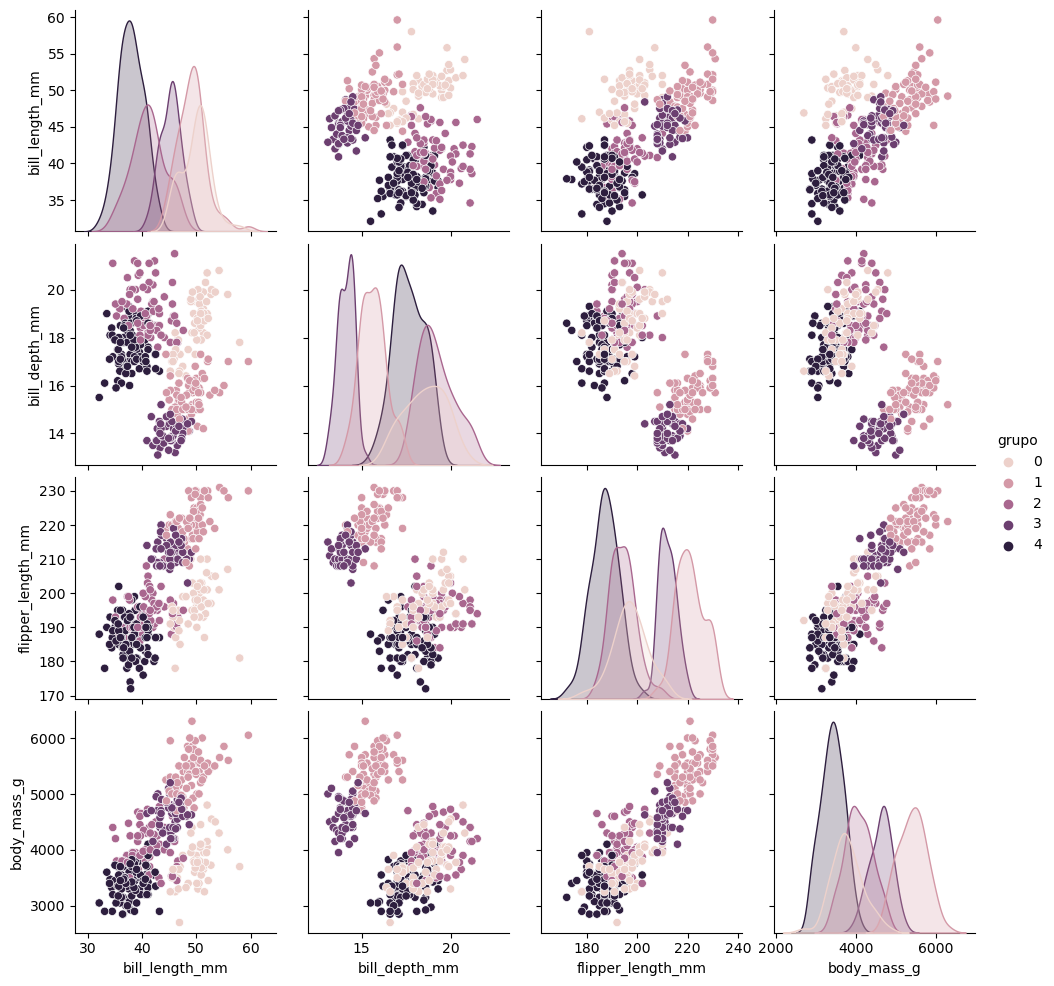

In [23]:
sns.pairplot(data = peng_num, hue = 'grupo')

A análise da tabela cruzada entre espécies, sexo e clusters revelou que a segmentação dos pinguins foi fortemente influenciada tanto pela espécie quanto pelo sexo dos indivíduos. A espécie Adelie se distribuiu principalmente entre dois grupos, com os machos concentrados no grupo 2 e as fêmeas no grupo 4. Já a espécie Gentoo apresentou uma separação ainda mais clara por sexo, com os machos exclusivamente no grupo 1 e as fêmeas no grupo 3. A espécie Chinstrap, por sua vez, foi majoritariamente agrupada no grupo 0, especialmente os machos, embora as fêmeas também tenham aparecido em menor número nos grupos 2 e 4. Essas observações confirmam a estrutura identificada no dendrograma, resultando em cinco grupos bem definidos, sendo dois para Adelie (divididos por sexo), dois para Gentoo (também por sexo) e um predominante para Chinstrap.